# Train a General Expected Threat Model

This notebook trains a grid-based expected threat model using processed
StatsBomb shots, successful passes, and carries.

In [34]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [35]:
DATA_ROOT = Path(r"D:\UIUC\Projects\World Cup 2026\Learning\output\processed_data")
actions = pd.read_parquet(DATA_ROOT)
display(actions.head())

,match_id,event_id,period,minute,second,team,player,event_type,start_x,start_y,end_x,end_y,success,goal
0,3895292,6c546c19-5f61-4236-a1ad-0b6f5cded692,1.0,0.0,1.0,Union Berlin,Brenden Aaronson,Pass,61.0,40.1,58.5,38.9,True,False
1,3895292,a7fdbea2-aabe-498d-ac0d-ebd6e3edabca,1.0,0.0,1.0,Union Berlin,András Schäfer,Pass,58.8,38.6,35.9,50.9,True,False
2,3895292,00724eb9-1285-4be4-8cc8-9231ccf63110,1.0,0.0,3.0,Union Berlin,Danilho Doekhi,Carry,35.9,50.9,37.9,52.2,True,False
3,3895292,f3647dd4-0731-472b-b2e8-31b01e772fc7,1.0,0.0,4.0,Union Berlin,Danilho Doekhi,Pass,37.9,52.2,86.1,6.0,True,False
4,3895292,ba8350af-91ff-4a29-a646-d88829863907,1.0,0.0,8.0,Union Berlin,Robin Gosens,Pass,84.3,6.2,94.2,16.7,False,False


Check the field that required for training


In [36]:
required_columns = [
    "match_id",
    "period",
    "event_type",
    "start_x",
    "start_y",
    "end_x",
    "end_y",
    "success",
    "goal",
]

missing_columns = [
    column
    for column in required_columns
    if column not in actions.columns
]

print("Missing columns:", missing_columns)

Missing columns: []


In [37]:
model_action = actions.copy()
coordinate_col = ["start_x","start_y","end_x","end_y"]
for col in coordinate_col:
    model_action[col] = pd.to_numeric(model_action[col],
    errors="coerce")

model_action["success"] = (
    model_action["success"].astype("boolean")
)

model_action["goal"] = (
    model_action["goal"].astype("boolean")
)

exclude penalty shoot-out

In [38]:
model_actions = model_action[
    model_action["period"].between(1, 4)
].copy()

extract shots, move successful(pass, carry)

In [39]:
shots = model_action[model_action["event_type"]=="Shot"]
shots = shots.dropna(subset=["start_x","start_y"]).copy()
move = model_action[model_action["event_type"].isin(["Pass","Carry"]) & model_action["success"].fillna(False)].copy()
move = move.dropna(subset=["start_x","start_y","end_x","end_y"]).copy()


Check the attacking forward direction. All the teams' attack direction should be from the left side to the right side

In [40]:
right_half_shot_share = (
    shots["start_x"] > 60
).mean()

print(
    "Share of shots from x > 60:",
    round(right_half_shot_share, 4),
)
display(
    shots[
        ["start_x", "start_y"]
    ].describe()
)

Share of shots from x > 60: 0.9963


,start_x,start_y
count,540.000000,540.000000
mean,104.155000,40.259074
std,8.363879,8.803247
min,57.700000,16.500000
25%,97.975000,33.575000
50%,105.300000,40.100000
75%,110.800000,46.200000
max,118.800000,65.900000


Define pitch and grid

In [41]:
PITCH_LENGTH = 120
PITCH_WIDTH = 80
N_X = 16
N_Y = 12

N_CELLS = N_X * N_Y

CELL_LENGTH = PITCH_LENGTH / N_X
CELL_WIDTH = PITCH_WIDTH / N_Y


第一行：0, 1, 2, ..., 15  
第二行：16, 17, ..., 31  
last row:176, ..., 191  
clip is a numpy function

In [42]:
def coordinates_to_cell_id(x, y):
    #Convert StatsBomb x-y coordinates into a single grid cell ID.

    x_bin = np.floor(
        x / CELL_LENGTH
    ).clip(0, N_X - 1).astype(int)
    #clip means boundary truncation. Sometime players would carry ouside the pitch, so there maybe some negative position
    y_bin = np.floor(
        y / CELL_WIDTH
    ).clip(0, N_Y - 1).astype(int)

    cell_id = y_bin * N_X + x_bin

    return cell_id

In [43]:
shots["start_cell"] = coordinates_to_cell_id(shots["start_x"],shots["start_y"])
move["start_cell"] = coordinates_to_cell_id(move["start_x"],move["start_y"])
move["end_cell"] = coordinates_to_cell_id(move["end_x"],move["end_y"])


In [44]:
shot_counts = np.bincount(
    shots["start_cell"].to_numpy(dtype=int),
    minlength=N_CELLS,
).astype(float)
#bincount is a numpy function
#Count the frequency of each integer in the non-negative integer array
move_counts = np.bincount(
    move["start_cell"].to_numpy(dtype=int),
    minlength=N_CELLS
).astype(float)

action_counts = shot_counts + move_counts
shot_prob = np.divide( #np.divide(a,b,out= , where=)
    shot_counts,#first parameter, dividend
    action_counts,# divisor
    out=np.zeros_like(shot_counts), #create a series which structure is same as "shot_counts".创造新的数组
    #out = 指定除法运算结果写入这个数组
    where=action_counts>0 #只有格子有持球记录才运行除法运算
    )
move_probability = np.divide(
    move_counts,
    action_counts,
    out=np.zeros_like(move_counts),
    where=action_counts > 0,
)
active_cells = action_counts > 0 #judgement, 

probability_sum_error = np.max(
    np.abs(
        shot_prob[active_cells]
        + move_probability[active_cells]
        - 1
    )
)

print(
    "Maximum probability sum error:",
    probability_sum_error,
)

Maximum probability sum error: 0.0


Count the goal probability in every grid.

In [45]:
goals = shots[
    shots["goal"].fillna(False)
].copy()
#Find out all the goals and then summarize the numbers of goals in every grid.
goal_counts = np.bincount(
    goals["start_cell"].to_numpy(dtype=int),
    minlength=N_CELLS,
).astype(float)
#calculate the goal probabilites
goal_probability = np.divide(
    goal_counts,
    shot_counts,
    out=np.zeros_like(goal_counts),
    where=shot_counts > 0,
)


Create a regional transfer matrix  
compile the times that ball were transitted from grid i to j  
np.zero(shape); np.one(shape),initialize the possibility matrix. Create a all zero 0, or all 1 numpy matrix.

In [46]:
transition_counts = np.zeros(
    (N_CELLS, N_CELLS),
    dtype=float,
)
#创建一个192*192的空矩阵
start_cells = move[
    "start_cell"
].to_numpy(dtype=int)
end_cells = move[
    "end_cell"
].to_numpy(dtype=int)


np.add.at(
    transition_counts,
    (start_cells, end_cells),
    1,
)

Convert the numbers of transfers ito probabilities  

transition_matrix[i,j] indicate the probability that ball was transfered form grid i to gird j

In [47]:
transition_row_totals = (
    transition_counts.sum(
        axis=1,
        keepdims=True,
    )
)
transition_matrix = np.divide(
    transition_counts,
    transition_row_totals,
    out=np.zeros_like(transition_counts),
    where=transition_row_totals > 0,
)

In [48]:
rows_with_moves = (
    transition_row_totals[:, 0] > 0
)

transition_sum_error = np.max(
    np.abs(
        transition_matrix[
            rows_with_moves
        ].sum(axis=1) - 1
    )
)

print(
    "Maximum transition row error:",
    transition_sum_error,
)

Maximum transition row error: 2.220446049250313e-16


In [49]:
xt = np.zeros(N_CELLS) #设立初始值，所有xT都为0
shot_value = (
    shot_prob
    * goal_probability
)#立即射门的初始值

In [69]:
#开始迭代
MAX_ITERATIONS = 1000#最大迭代次数上限
TOLERANCE = 0.0001 #收敛阈值，一轮迭代前后，xT的变化小于这个数就停止迭代

convergence_history = []

for iteration in range(
    1, MAX_ITERATIONS):

    move_value = (
        transition_matrix @ xt #矩阵乘法
    )

    new_xt = (
        shot_value
        + move_probability * move_value
    )

    maximum_change = np.max( #np.max:找出网格中变化最大的值
        np.abs(new_xt - xt) #np.abs取绝对值
    )

    convergence_history.append(
        maximum_change
    )
    xt = new_xt

    if maximum_change < TOLERANCE:
        print(
        f"Converged after "
        f"{iteration} iterations"
        )
        break


Converged after 84 iterations


In [70]:
print("Minimum xT:", xt.min())
print("Maximum xT:", xt.max())

Minimum xT: 0.07589915007015413
Maximum xT: 0.3061503140339469


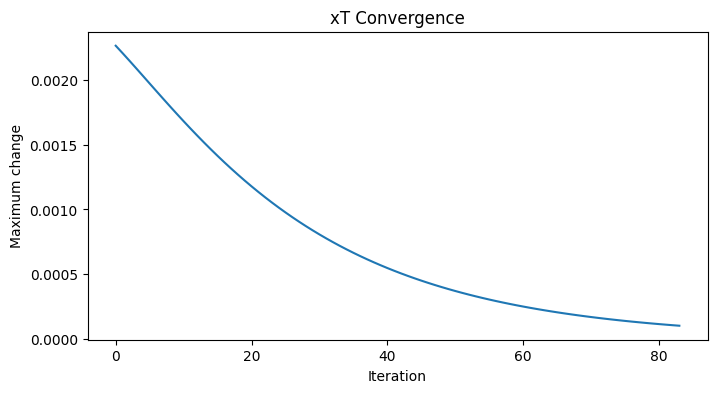

In [71]:
plt.figure(figsize=(8, 4))

plt.plot(convergence_history)

plt.title("xT Convergence")
plt.xlabel("Iteration")
plt.ylabel("Maximum change")

plt.show()

In [72]:
xt_grid = xt.reshape(N_Y,N_X)
print(xt_grid.shape)

(12, 16)


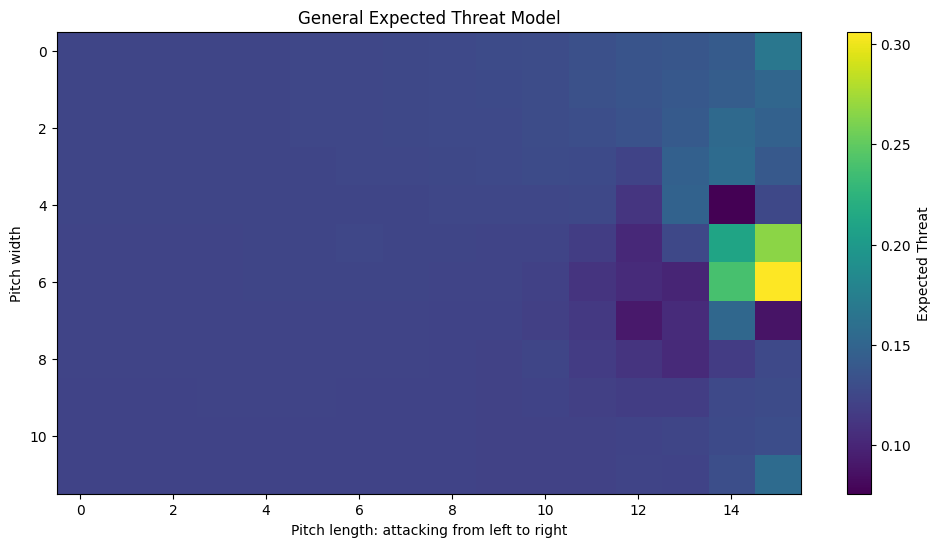

In [73]:
plt.figure(figsize=(12, 6))

image = plt.imshow(
    xt_grid,
    origin="upper",
    aspect="auto",
)

plt.colorbar(
    image,
    label="Expected Threat",
)

plt.title(
    "General Expected Threat Model"
)

plt.xlabel(
    "Pitch length: attacking from left to right"
)

plt.ylabel(
    "Pitch width"
)

plt.show()

In [85]:
convergence_history = []
xt_history =[]
xt = np.zeros(N_CELLS)
for iteration in range(0,10):
    move_value = transition_matrix @xt
    new_xt = shot_value + move_value*move_probability
    xt = new_xt
    xt_history.append(xt.reshape(N_Y, N_X).copy())

C:\Users\Liuhy\AppData\Local\Temp\ipykernel_53240\2701484482.py:60: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


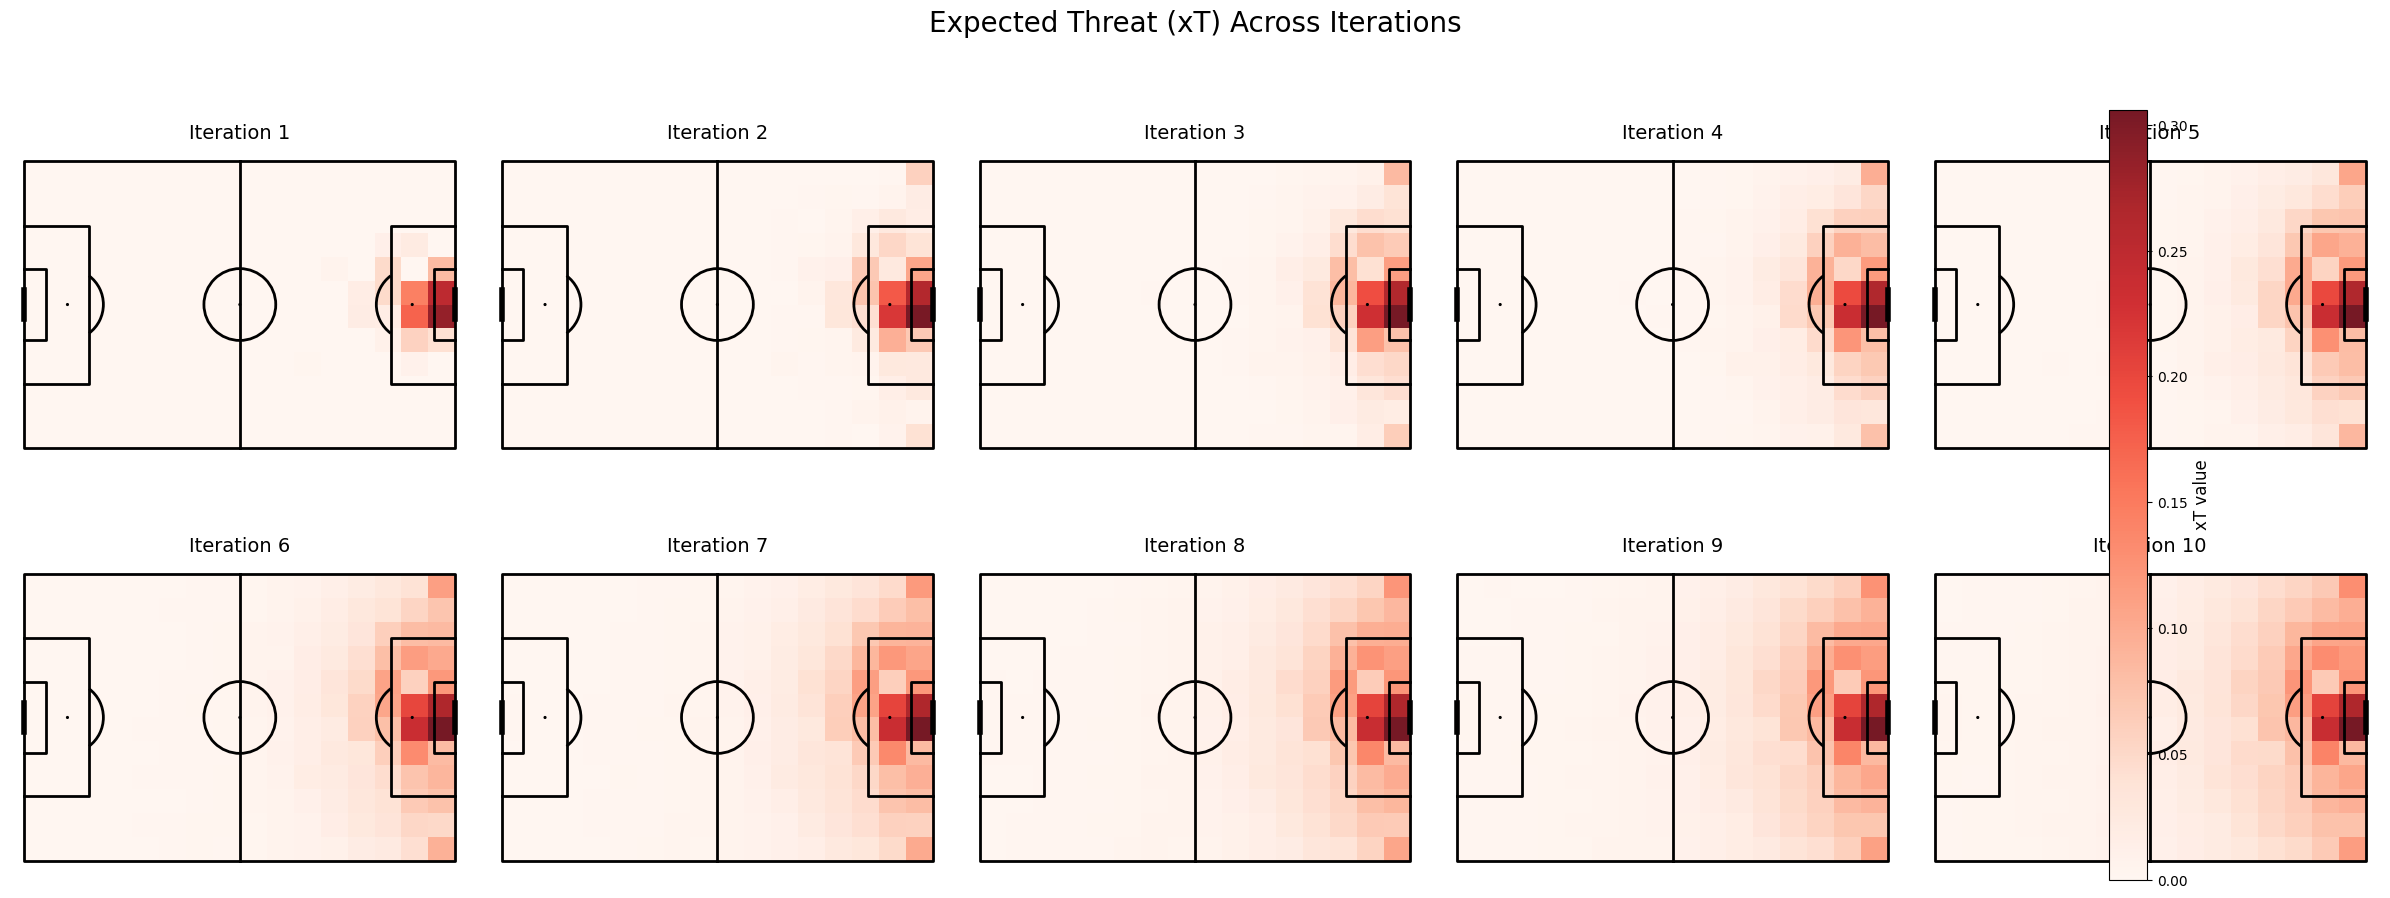

In [87]:
from mplsoccer import Pitch
# 球场参数
PITCH_LENGTH = 120
PITCH_WIDTH = 80

# 网格边界
x_edges = np.linspace(0, PITCH_LENGTH, N_X + 1)
y_edges = np.linspace(0, PITCH_WIDTH, N_Y + 1)

# 为了让10张图颜色可比，统一 color scale
vmin = min(grid.min() for grid in xt_history)
vmax = max(grid.max() for grid in xt_history)

pitch = Pitch(
    pitch_type="statsbomb",
    pitch_color="white",
    line_color="black",
    line_zorder=2
)

fig, axes = plt.subplots(2, 5, figsize=(24, 10))
axes = axes.flatten()

last_mesh = None

for i, ax in enumerate(axes):
    pitch.draw(ax=ax)

    xt_grid = xt_history[i]

    # 用 pcolormesh 将 xT 网格覆盖到球场上
    last_mesh = ax.pcolormesh(
        x_edges,
        y_edges,
        xt_grid,
        cmap="Reds",
        vmin=vmin,
        vmax=vmax,
        shading="auto",
        alpha=0.9,
        zorder=1
    )

    ax.set_title(f"Iteration {i+1}", fontsize=14)

fig.suptitle(
    "Expected Threat (xT) Across Iterations",
    fontsize=20,
    y=0.98
)

cbar = fig.colorbar(
    last_mesh,
    ax=axes.tolist(),
    fraction=0.025,
    pad=0.02
)
cbar.set_label("xT value", fontsize=12)

plt.tight_layout()
plt.show()

In [88]:
MODEL_DIR = Path("processed_data")
MODEL_DIR.mkdir(parents=True, exist_ok=True)

XT_MODEL_PATH = MODEL_DIR / "general_xt_model.npy"

np.save(XT_MODEL_PATH, xt_grid)

print("Saved xT model to:", XT_MODEL_PATH)
print("Model shape:", xt_grid.shape)

Saved xT model to: processed_data\general_xt_model.npy
Model shape: (12, 16)
